In [1]:
import os
from typing import List

import pandas as pd
import numpy as np
import scanpy as sc

import torch
import torch.nn as nn
from geomloss import SamplesLoss

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


from sklearn.neighbors import NearestCentroid


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import cross_condition_distances
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import calculate_pairwise_distances, get_upper_triangle, cohen_d, quantify_cluster_distance

In [3]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

Load data:

In [4]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [6]:
tf_labels = tf_adata.var_names
ligand_labels = ['IFNB1']

Filter expression matrix for HVGs:

In [7]:
# adata = adata[:, adata.var[adata.var['highly_variable']].index] # filter for HVGs for simplicity <-- already filtered for HVGs
# expr = sc.pp.scale(expr, copy = True)


# start dev

In [8]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,407,185,859,978,352,2215,507,258,23,115,298,300,51,6548
STIM,571,203,903,1526,462,2147,537,214,32,121,321,333,81,7451
Total,978,388,1762,2504,814,4362,1044,472,55,236,619,633,132,13999


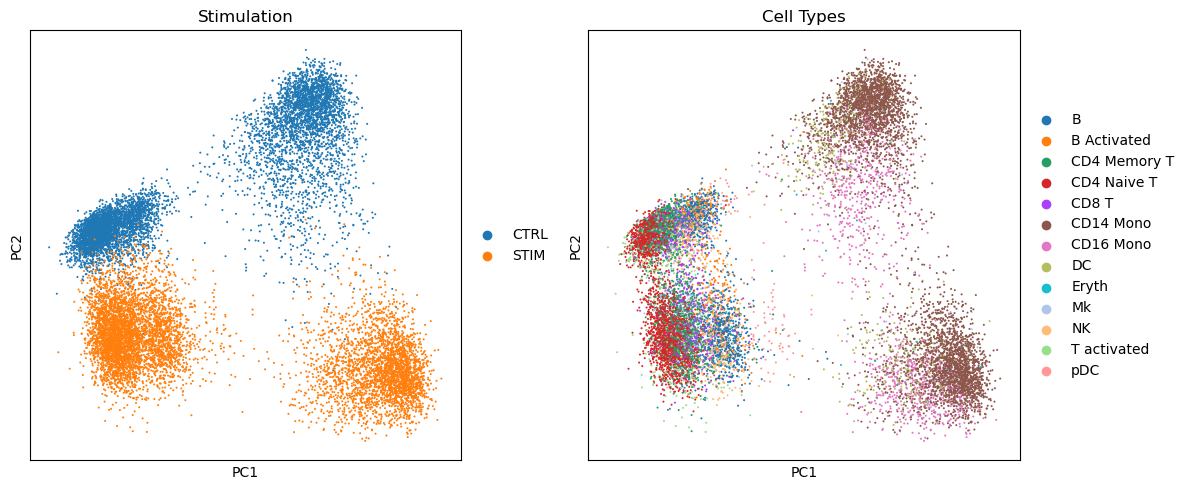

In [9]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5))

# sc.pl.umap(adata, color='leiden', ax = ax[0], show = False)
# ax[0].set_title('Clusters')
# ax[0].legend().set_visible(False)
# # ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(adata, color='stim', ax = ax[0], show = False)
ax[0].set_title('Stimulation')
# ax[1].legend().set_visible(False)

sc.pl.pca(adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
# ax[1].legend().set_visible(False)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

In [10]:
distance_df = cross_condition_distances(adata = tf_adata, 
                            column_1 = 'seurat_annotations', 
                            column_2 = 'stim', 
                            n_pcs = tf_adata.uns['pca']['pca_rank'])
distance_df.sort_values(by = 'distance', ascending = False).reset_index(drop = True)

,seurat_annotations,stim_1,stim_2,distance
0,CD14 Mono,CTRL,STIM,6.019051
1,DC,CTRL,STIM,5.435884
2,B,CTRL,STIM,5.358378
3,CD16 Mono,CTRL,STIM,4.933902
4,pDC,CTRL,STIM,4.871000
5,CD4 Naive T,CTRL,STIM,4.651253
6,NK,CTRL,STIM,4.379271
7,CD4 Memory T,CTRL,STIM,4.231110
8,Eryth,CTRL,STIM,4.192032
9,Mk,CTRL,STIM,3.934170


In [11]:
backup_tf_adata = tf_adata.copy()

In [12]:
tf_adata = backup_tf_adata.copy()

In [13]:
subset_cells = []
n_cells = 200

for ct in tf_adata.obs['seurat_annotations'].unique():
    cells = tf_adata.obs[tf_adata.obs['seurat_annotations'] == ct].index.tolist()
    if len(cells) > n_cells:
        np.random.seed(seed)
        cells = list(np.random.choice(cells, n_cells, replace = False))
    subset_cells += cells
len(subset_cells)

2387

In [14]:
tf_adata = tf_adata[subset_cells, :]
adata = adata[subset_cells, :]

n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, 4)).astype(int)[1:-1])

In [15]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,91,96,108,71,87,100,97,115,23,102,97,101,51,1139
STIM,109,104,92,129,113,100,103,85,32,98,103,99,81,1248
Total,200,200,200,200,200,200,200,200,55,200,200,200,132,2387


In [16]:
tf_adata.obs['stim'].unique()

['STIM', 'CTRL']
Categories (2, object): ['CTRL', 'STIM']

In [17]:
test_cells = tf_adata.obs[(tf_adata.obs['seurat_annotations'] == 'DC') & (tf_adata.obs['stim'] == 'STIM')].index.tolist()
train_cells = tf_adata.obs[~((tf_adata.obs['seurat_annotations'] == 'DC') & (tf_adata.obs['stim'] == 'STIM'))].index.tolist()

ligand_input = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1'])
tf_output = pd.DataFrame(tf_adata.X, index = tf_adata.obs.index, columns = tf_adata.var.index)


In [18]:
me = 70
max_lr = 1e-3
lr_scaling_factor = 10
lr_period = 2

train_batch_factor = 4
test_batch_factor = 1

In [19]:
# linear scaling of inputs/outputs
projection_amplitude_in = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
lr_params = {'max_epochs': me, 'maximum_learning_rate': max_lr, 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(me/lr_period), 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': int(me/10)}

other_params = {'train_batch_size': round(len(train_cells)/train_batch_factor), 
                'test_batch_size': round(len(test_cells)/test_batch_factor), 'validation_batch_size': np.nan, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
target_spectral_radius = 0.8

In [20]:
projection_amplitude_out = 1

In [21]:
regularization_params = {'input_lambda_L2': 0, 
                         'bn_weights_lambda_l2': 0, 
                         'bn_bias_lambda_L2': 0, # 5e-8
                         'output_weights_lambda_L2': 0,
                         'output_bias_lambda_L2': 0,
                         'moa_lambda_L1': 0,  
                         'uniform_lambda_L2': 0,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 0, 
                        'vae_scaling_KL': 1e-2}

# regularization_params = {'input_lambda_L2': 1e-4, 
#                          'bn_weights_lambda_l2': 1e-4, 
#                          'bn_bias_lambda_L2': 0, # 5e-8
#                          'output_weights_lambda_L2': 1e-4,
#                          'output_bias_lambda_L2': 1e-4,
#                          'moa_lambda_L1': 0,  
#                          'uniform_lambda_L2': 0,#, 1e-5,
#                          'uniform_min': 0,
#                          'uniform_max': 1, 
#                          'spectral_loss_factor': 0,
#                         'vae_lambda_l2': 1e-4, 
#                         'vae_scaling_KL': 1e-3}


discriminator_params = {'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': nn.LeakyReLU,
 'n_hidden_nodes': [768, 512, 256],
 'maximum_learning_rate': max_lr,
 'minimum_learning_rate':max_lr/lr_scaling_factor,
 'lr_restart_epoch': int(me/lr_period),
 'reset_optimizer_epoch': 200,
 'lr_decay': 0.9,
 'lr_restart_factor': 1,
 'warmup_epochs': int(me/10),
 'optimizer': torch.optim.Adam,
 'discriminator_lambda_L2': 0,
                        'discriminator_penalty_weight': 0.001}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}

In [31]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = adata.to_df(), 
                     covariates = tf_adata.obs,
                     categorical_covariate_keys = ['seurat_annotations'],
                     projection_amplitude_in = projection_amplitude_in, 
                     projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

In [32]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)

In [33]:

mod = trainer.train_model(verbose = True)

# torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
# io.write_pickled_object(trainer,  os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))

  1%|█                                                                           | 1/70 [00:02<02:22,  2.06s/it]

i=0, l(tr)=91.46615, s=0.22056, r=0.00010, v=0.00000


100%|███████████████████████████████████████████████████████████████████████████| 70/70 [02:14<00:00,  1.92s/it]

Training ran in: 2 min 14.30 sec


In [34]:
train_stats_df = trainer.stats['train'].copy()
# test_stats_df = trainer.stats['test'].copy()

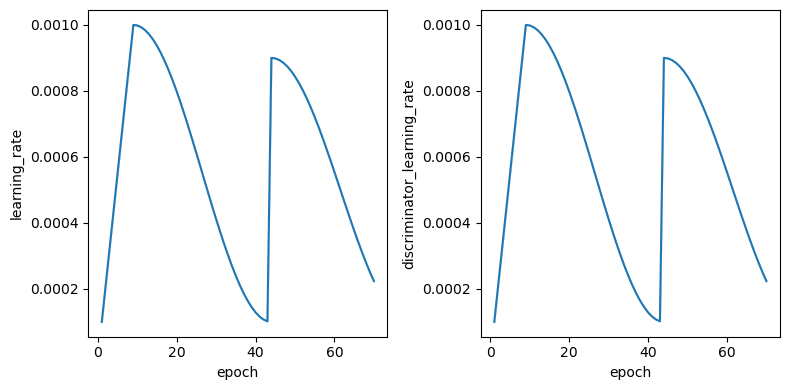

In [35]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
fig.tight_layout()

/tmp/ipykernel_156614/3670132255.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viz_df = viz_df.groupby(['epoch', 'loss_type']).mean().reset_index()
/tmp/ipykernel_156614/3670132255.py:45: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
/tmp/ipykernel_156614/3670132255.py:58: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])


Text(0.5, 1.0, 'Train Loss - with Adverserial')

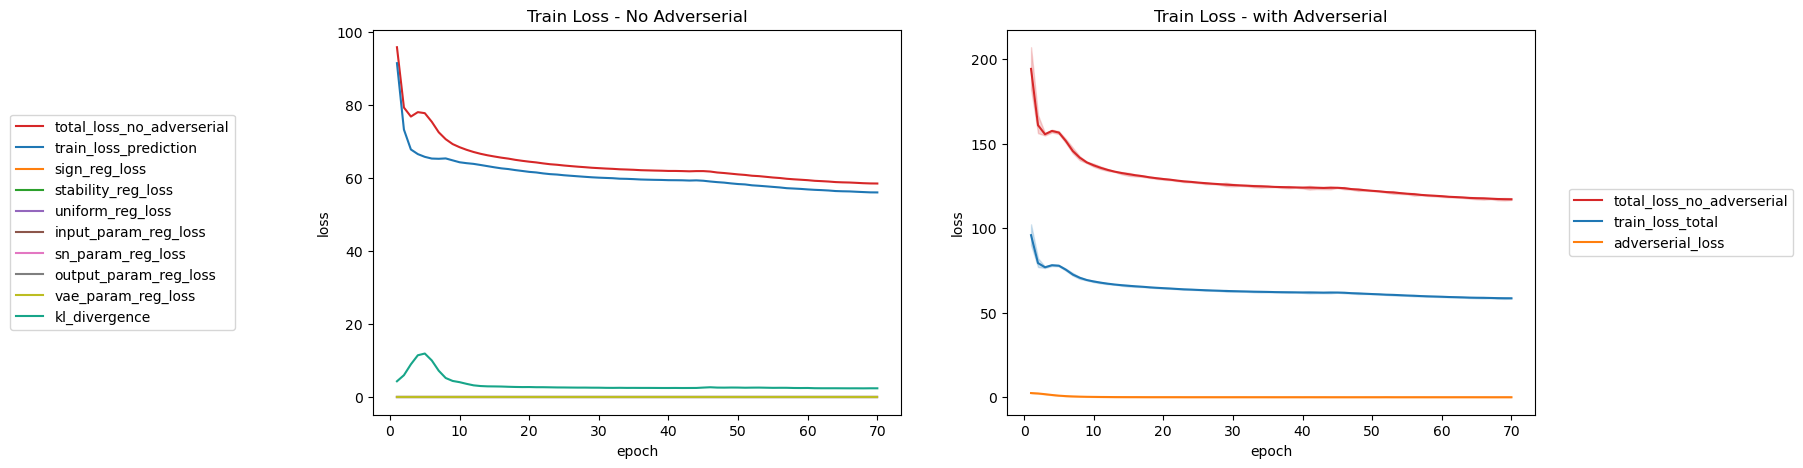

In [36]:
# font_scaling_factor = 1.2
# with plt.rc_context({
#     'font.size': plt.rcParams['font.size'] * font_scaling_factor,
#     'axes.titlesize': plt.rcParams['axes.titlesize'] * font_scaling_factor,
#     'axes.labelsize': plt.rcParams['axes.labelsize'] * font_scaling_factor,
#     'xtick.labelsize': plt.rcParams['xtick.labelsize'] * font_scaling_factor,
#     'ytick.labelsize': plt.rcParams['ytick.labelsize'] * font_scaling_factor,
#     'legend.fontsize': plt.rcParams['legend.fontsize'] * font_scaling_factor
# }):


fig, ax = plt.subplots(ncols = 2, figsize = (15,5))

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']

viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

# TODO: delete this next line
viz_df = viz_df.groupby(['epoch', 'loss_type']).mean().reset_index()

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
# ax[0].set_yscale('log')
ax[0].legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax[0].set_title('Train Loss - No Adverserial')


loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']
viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
# ax[0].set_yscale('log')
ax[1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
ax[1].set_title('Train Loss - with Adverserial')
# ax[0].set_yscale('symlog')


In [37]:
viz_df.head()

,epoch,loss_type,loss
0,1.0,train_loss_total,105.423866
1,1.0,train_loss_total,98.018776
2,1.0,train_loss_total,92.678055
3,1.0,train_loss_total,87.194313
4,2.0,train_loss_total,83.835075


/tmp/ipykernel_156614/1983991382.py:10: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)


Text(0.5, 1.0, 'Discriminator Loss')

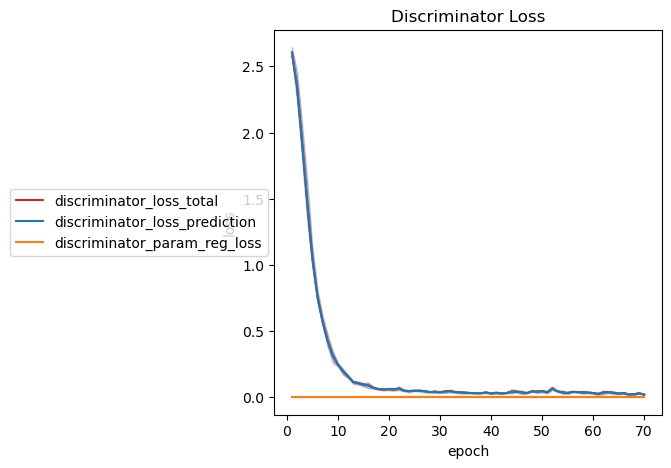

In [38]:
fig, ax = plt.subplots(ncols = 1, figsize = (5,5))


loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']
viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)
# ax[0].set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax.set_title('Discriminator Loss')


In [260]:
# # inputs
# X_train = mod.df_to_tensor(trainer.X_train)
# y_train = mod.df_to_tensor(trainer.y_train)
# expr_train = mod.df_to_tensor(mod.expr.loc[trainer.X_train.index, :])
# covariates_idx_train = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_train.index)

# # run prediction
# mod.eval()
# with torch.inference_mode():
#     Y_hat, Y_full, biases = mod(X_in = X_train, covariates_idx = covariates_idx_train, expr = expr_train)
#     bias_global, bias_mu, bias_log_sigma_squared = biases

# # formatting
# y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
# y_predicted.index, y_predicted.columns = trainer.y_train.index, trainer.y_train.columns

In [ ]:
# X_train = mod.df_to_tensor(trainer.X_train)
# y_train = mod.df_to_tensor(trainer.y_train)

In [64]:
# inputs
X_test = mod.df_to_tensor(trainer.X_test)
y_test = mod.df_to_tensor(trainer.y_test)
expr_test = mod.df_to_tensor(mod.expr.loc[trainer.X_test.index, :])
covariates_idx_test = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_test.index)

# run prediction
mod.eval()
with torch.inference_mode():
    Y_hat, Y_full, biases = mod(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
    bias_global, bias_mu, bias_log_sigma_squared = biases

# formatting
y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
y_predicted.index, y_predicted.columns = trainer.y_test.index, trainer.y_test.columns

In [65]:
n_perm = 10

In [8]:
primary_comparison = calculate_pairwise_distances(y_predicted, 
                                                  trainer.y_test, 
                                                  distance_metric = 'euclidean',
                                                  invert_corr = True,
                                                  axis = 0).values.flatten()
# ---------------------------------
experimental_comparison = get_upper_triangle(calculate_pairwise_distances(trainer.y_test, 
                                                  distance_metric = 'euclidean',
                                                  invert_corr = True,
                                                  axis = 0))

# ------------baseline 1: within vs across perturbation distance------------
md_ = tf_adata.obs[tf_adata.obs.seurat_annotations == ct]
# filter to cell of interest
ctrl_cells = md_[md_.stim == 'STIM'].index.tolist()
stim_cells = md_[md_.stim == 'CTRL'].index.tolist()

ctrl_X = tf_adata[ctrl_cells, :].to_df()
stim_X = tf_adata[stim_cells, :].to_df()
# get pairwise distances
baseline_1 = calculate_pairwise_distances(df1 = ctrl_X,
                                        df2 = stim_X,
                                        distance_metric = 'euclidean',
                                        axis = 0, # compare the cells
                                       ).values.flatten()

# ------------baseline 2: distance to random------------
# TODO: modify the label and comparison_combination_subsets if have multiple cell types in on
md = tf_adata[trainer.y_test.index, :].obs.copy()
md = pd.concat([md, md])
md['prediction'] = ['actual']*trainer.y_test.shape[0] + ['predicted']*y_predicted.shape[0]
md['prediction'] = md['prediction'].astype(str)
tf_adata_b2 = sc.AnnData(X = pd.concat([trainer.y_test, y_predicted]), obs = md)

baseline_2 = quantify_cluster_distance(tf_adata = tf_adata_b2,
                          label = 'prediction', 
                              comparison_combination_subset = None,
                              comparison_subset = None,
                              label_subset = None,
                              include_self = False, 
                              feature_subset = None,
                              distance_metric = 'euclidean',
                              normal = True, 
                              use_pcs = False,
                              rank = None, 
                              n_perm = n_perm, 
                              alternative = 'less', 
                              seed = 888, 
                             n_cores = 1)

baseline_2_emd = quantify_emd(tf_adata = tf_adata_b2, 
                              label = 'prediction', 
                              comparison_combination_subset = None,
                              comparison_subset = None, 
                              label_subset = None,
                              include_self = False,
                              feature_subset = None,
                              use_pcs = False, 
                              rank = None, 
                              n_perm = n_perm, 
                              alternative = 'less', 
                              seed = 888,
                              n_cores = 1,
                              device = device, 
                              emd_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(default_device))

# ------------baseline 3: random model------------

# you are here:
- visualization
- difference in differences (cohen's d comparisons)

In [ ]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_train, axis=1, return_mean=False)

In [ ]:
fig, ax = plt.subplots()
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')

# sns.histplot(spearmans, ax = ax)
;

In [ ]:
pca_mod = tf_adata.uns['pca']['pca_mod']
rank = tf_adata.uns["pca"]['pca_rank']


md = tf_adata.obs
md['condition'] = tf_adata.obs['seurat_annotations'].astype(str) + '^' + tf_adata.obs['stim'].astype(str)

X_pca = pd.DataFrame(tf_adata.obsm['X_pca'][:, :rank], 
                 index = tf_adata.obs.index, 
                columns = ['PC_{}'.format(i + 1) for i in range(rank)])
clf = NearestCentroid()
clf.fit(X_pca, md['condition'])
X_pca_centroids = pd.DataFrame(clf.centroids_, columns = clf.feature_names_in_, index = clf.classes_)

In [ ]:
viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)

In [ ]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')
ax[0].legend().set_visible(False)



y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')
ax[1].legend().set_visible(False)

fig.tight_layout()



In [ ]:
# inputs
X_test = mod.df_to_tensor(trainer.X_test)
y_test = mod.df_to_tensor(trainer.y_test)
expr_test = mod.df_to_tensor(mod.expr.loc[trainer.X_test.index, :])
covariates_idx_test = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_test.index)

# run prediction
mod.eval()
with torch.inference_mode():
    Y_hat, Y_full, biases = mod(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
    bias_global, bias_mu, bias_log_sigma_squared = biases

# formatting
y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
y_predicted.index, y_predicted.columns = trainer.y_test.index, trainer.y_test.columns

In [ ]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_test, axis=1, return_mean=False)

In [ ]:
fig, ax = plt.subplots(figsize = (4,3))
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')
;

In [ ]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_test.index, :], pd.DataFrame(md.loc[trainer.y_test.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')
ax[0].legend().set_visible(False)



y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_test.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')
ax[1].legend().set_visible(False)

fig.tight_layout()